# imports

In [1]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [2]:
imp_med = SimpleImputer(missing_values=np.nan, strategy='median')
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [3]:
path = './data/'
csv_path = path + 'to_input_openfoodfacts.csv'
sm_df = pd.read_csv(csv_path, low_memory=False)

# Dataframe info

## functions

In [4]:
def get_df_columns_na(df):
    counts = df.isna().sum()
    percentages = round(df.isna().mean() * 100, 1)
    null_values = pd.concat([counts, percentages], axis = 1, keys = ["count", "null_percent"])
    null_values['columns'] = null_values.index
    null_values = null_values[['columns', 'count', 'null_percent']]
    return null_values

In [5]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [50]:
def simple_show_nulls(df):
    top_sm_df_sort = get_df_columns_na(sm_df).sort_values(by='null_percent',ascending=False)
    return top_sm_df_sort

In [6]:
def show_nulls(df):
    top_sm_df_sort = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(top_sm_df_sort)
    return plot_df_xy(top_sm_df_sort.reset_index(), 'null_percent', 'columns', 8)

## General distribution / NaNs 

In [7]:
sm_df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,000000001576,Pur jus de pomme,0.0,b,Beverages,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,00000006,Riz au lait,4.0,c,Milk and dairy products,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,00000038,Pizza prosciutto,5.0,c,Composite foods,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600


In [8]:
sm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35707 entries, 0 to 35706
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                35707 non-null  object 
 1   product_name        35707 non-null  object 
 2   nutriscore_score    35707 non-null  float64
 3   nutriscore_grade    35707 non-null  object 
 4   pnns_groups_1       32065 non-null  object 
 5   energy-kcal_100g    34946 non-null  float64
 6   fat_100g            35087 non-null  float64
 7   saturated-fat_100g  35644 non-null  float64
 8   carbohydrates_100g  35608 non-null  float64
 9   sugars_100g         35615 non-null  float64
 10  proteins_100g       35650 non-null  float64
 11  salt_100g           35639 non-null  float64
 12  sodium_100g         35644 non-null  float64
dtypes: float64(9), object(4)
memory usage: 3.5+ MB


In [9]:
sm_df.describe()

,nutriscore_score,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,35707.000000,34946.000000,35087.000000,35644.000000,35608.000000,35615.000000,35650.000000,35639.000000,35644.000000
mean,8.661411,232.857746,14.123830,5.697903,10.635940,3.279121,12.865959,1.388721,0.561134
std,8.081851,155.971983,14.552291,7.699205,17.220582,6.470352,10.143935,1.967281,0.920148
min,-15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,116.000000,2.300000,0.600000,0.500000,0.200000,3.600000,0.200000,0.080000
50%,9.000000,203.000000,9.400000,2.600000,2.500000,0.800000,12.000000,1.000000,0.400000
75%,15.000000,341.000000,23.000000,8.400000,12.000000,2.900000,21.000000,1.800000,0.720000
max,35.000000,899.000000,99.900000,95.000000,99.000000,97.000000,99.000000,67.000000,44.000000


In [37]:
#sm_df.columns.to_list()

In [33]:
sm_num_cols = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
energy_cols = ['energy-kcal_100g']
scores_cols = ['nutriscore_score', 'nutriscore_grade', 
               #'ecoscore_grade'
              ]

<AxesSubplot:>

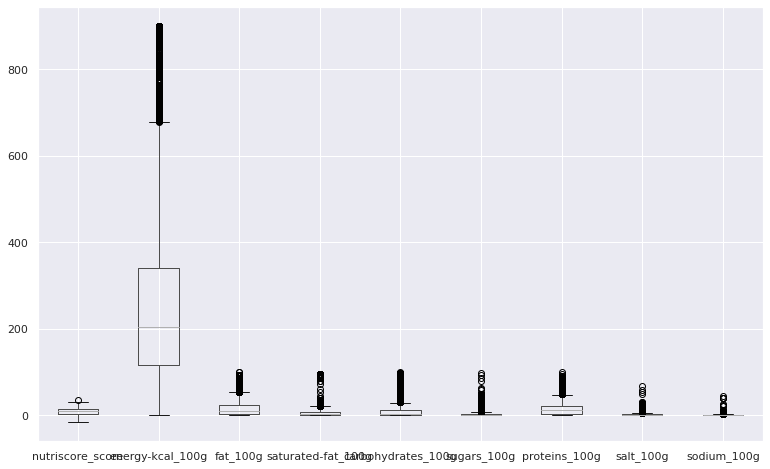

In [39]:
sm_df.boxplot()

[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

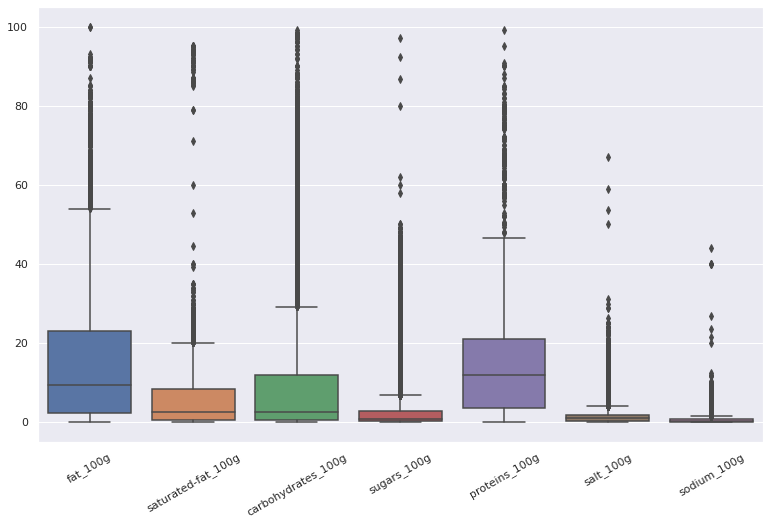

In [34]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'energy-kcal_100g')]

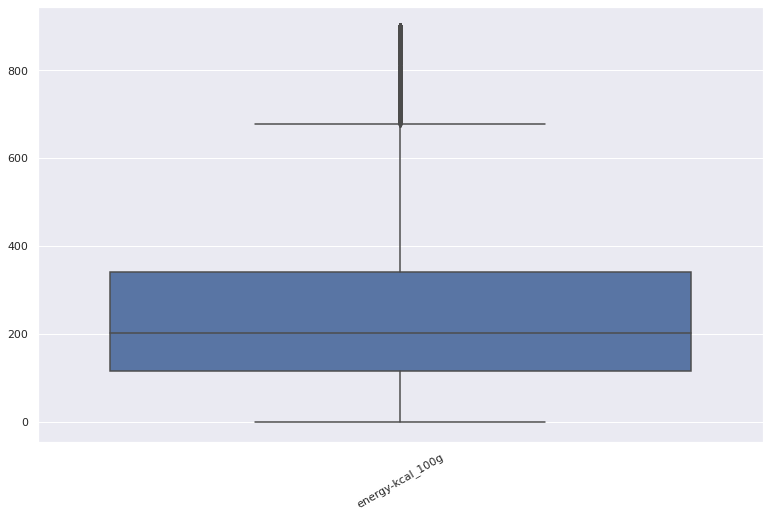

In [35]:
ax = sns.boxplot(data=sm_df[energy_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'nutriscore_score')]

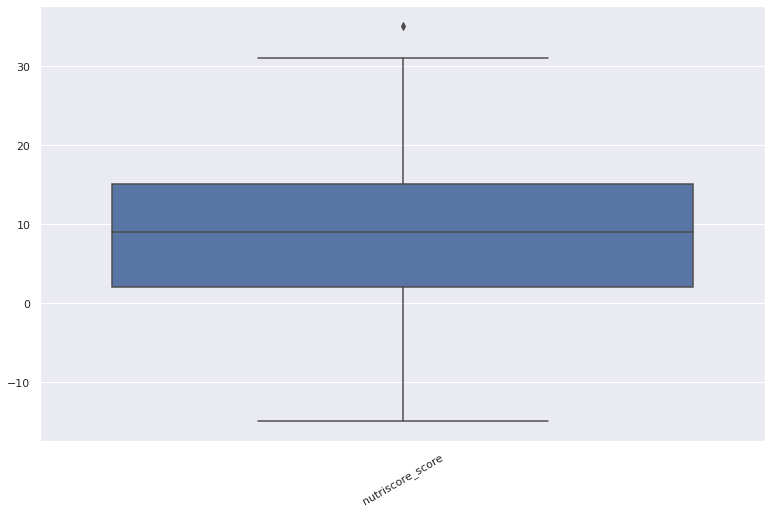

In [36]:
ax = sns.boxplot(data=sm_df[scores_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [12]:
## initial (2 282 517, 186)

sm_df.shape

(35707, 13)

In [13]:
#sm_df.isna().sum()

                               columns  count  null_percent
pnns_groups_1            pnns_groups_1   3642          10.2
energy-kcal_100g      energy-kcal_100g    761           2.1
fat_100g                      fat_100g    620           1.7
carbohydrates_100g  carbohydrates_100g     99           0.3
sugars_100g                sugars_100g     92           0.3
saturated-fat_100g  saturated-fat_100g     63           0.2
proteins_100g            proteins_100g     57           0.2
salt_100g                    salt_100g     68           0.2
sodium_100g                sodium_100g     63           0.2
code                              code      0           0.0
product_name              product_name      0           0.0
nutriscore_score      nutriscore_score      0           0.0
nutriscore_grade      nutriscore_grade      0           0.0


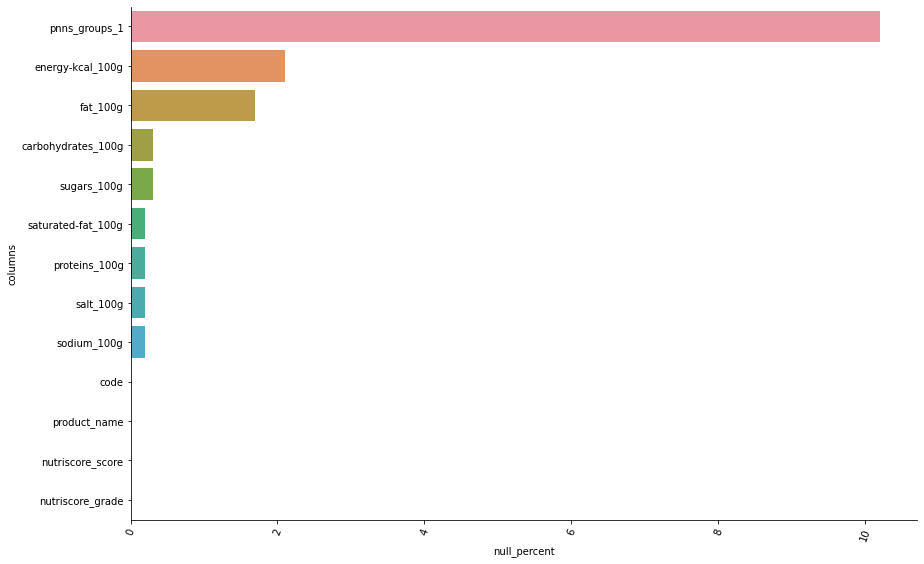

In [14]:
show_nulls(sm_df)

## Categories / "unknown"

In [15]:
main_cats = sm_df['pnns_groups_1'].unique()
main_cats

array(['Salty snacks', 'Beverages', 'Milk and dairy products',
       'Composite foods', 'Fat and sauces', 'Cereals and potatoes',
       'Fish Meat Eggs', 'Sugary snacks', nan, 'Fruits and vegetables',
       'Alcoholic beverages'], dtype=object)

In [16]:
sm_df['pnns_groups_1'].value_counts()

Fish Meat Eggs             12759
Milk and dairy products     4819
Composite foods             2918
Salty snacks                2587
Fat and sauces              2469
Cereals and potatoes        2082
Fruits and vegetables       1646
Sugary snacks               1536
Beverages                   1246
Alcoholic beverages            3
Name: pnns_groups_1, dtype: int64

In [17]:
all_cats = sm_df['pnns_groups_1'].unique().tolist()
all_cats

['Salty snacks',
 'Beverages',
 'Milk and dairy products',
 'Composite foods',
 'Fat and sauces',
 'Cereals and potatoes',
 'Fish Meat Eggs',
 'Sugary snacks',
 nan,
 'Fruits and vegetables',
 'Alcoholic beverages']

In [18]:
all_cols = sm_df.columns
all_cols

Index(['code', 'product_name', 'nutriscore_score', 'nutriscore_grade',
       'pnns_groups_1', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [19]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [20]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats

['code',
 'product_name',
 'nutriscore_score',
 'nutriscore_grade',
 'pnns_groups_1',
 'energy-kcal_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g']

In [21]:
all_cols

Index(['code', 'product_name', 'nutriscore_score', 'nutriscore_grade',
       'pnns_groups_1', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [22]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

Index(['nutriscore_score', 'energy-kcal_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

# Inputing

## categories : most frequent

### label encode categories 

In [44]:
sm_df['pnns_groups_1'].value_counts()

Fish Meat Eggs             12759
Milk and dairy products     4819
Composite foods             2918
Salty snacks                2587
Fat and sauces              2469
Cereals and potatoes        2082
Fruits and vegetables       1646
Sugary snacks               1536
Beverages                   1246
Alcoholic beverages            3
Name: pnns_groups_1, dtype: int64

In [23]:
sm_df.shape

(35707, 13)

In [ ]:
## categorical pnn1 

## inputing valeur vides avec valeur plus fréQUENTE / SIMPLE IMPUTER _ strategy most _frequent
# SimpleImputer(strategy="most_frequent")

In [40]:
from sklearn.impute import SimpleImputer

In [53]:
imp_fre = SimpleImputer(missing_values=np.nan, strategy= 'most_frequent')

In [61]:
imp_pnns = imp_fre.fit_transform(sm_df[['pnns_groups_1', 'nutriscore_score']])
imp_pnns

array([['Salty snacks', 21.0],
       ['Beverages', 0.0],
       ['Salty snacks', 14.0],
       ...,
       ['Milk and dairy products', 10.0],
       ['Fish Meat Eggs', 1.0],
       ['Milk and dairy products', 7.0]], dtype=object)

In [63]:
sm_df[['pnns_groups_1', 'nutriscore_score']] = imp_pnns

In [64]:
simple_show_nulls(sm_df)

,columns,count,null_percent
energy-kcal_100g,energy-kcal_100g,761,2.1
fat_100g,fat_100g,620,1.7
carbohydrates_100g,carbohydrates_100g,99,0.3
sugars_100g,sugars_100g,92,0.3
saturated-fat_100g,saturated-fat_100g,63,0.2
proteins_100g,proteins_100g,57,0.2
salt_100g,salt_100g,68,0.2
sodium_100g,sodium_100g,63,0.2
code,code,0,0.0
product_name,product_name,0,0.0


In [65]:
sm_df[['pnns_groups_1', 'nutriscore_score']].head()

,pnns_groups_1,nutriscore_score
0,Salty snacks,21.0
1,Beverages,0.0
2,Salty snacks,14.0
3,Milk and dairy products,4.0
4,Composite foods,5.0


In [90]:
sm_df['pnns_groups_1'].value_counts()

Fish Meat Eggs             16401
Milk and dairy products     4819
Composite foods             2918
Salty snacks                2587
Fat and sauces              2469
Cereals and potatoes        2082
Fruits and vegetables       1646
Sugary snacks               1536
Beverages                   1246
Alcoholic beverages            3
Name: pnns_groups_1, dtype: int64

## numerical values

In [73]:
### appliquer imputer différentes strategies (check distribution) avec un groupby categories
### iterative imputer / estimation du choix d'imputer selon la distribution (mean/median/most frequent...)


In [71]:
# Use mean imputation if variables are normally distributed and median imputation otherwise. 
# Mean and median imputation may distort 
# the distribution of the original variables if there is a high percentage of missing data.

In [68]:
sm_num_cols

['fat_100g',
 'saturated-fat_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g',
 'salt_100g',
 'sodium_100g']

[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

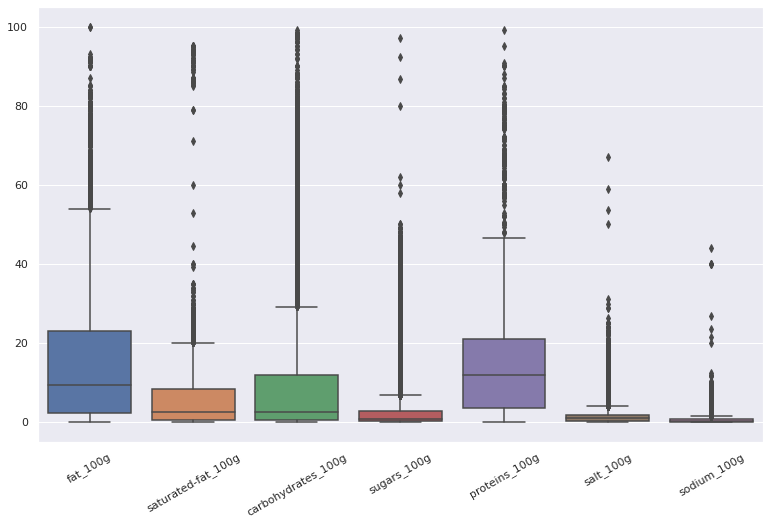

In [72]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [69]:
energy_cols

['energy-kcal_100g']

### sm_num_cols : fat / salt => median input

In [77]:
# sm_df[[c for c in df.columns if c in main_cats]].head()

In [73]:
sm_df.filter(sm_num_cols).head()

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,4.70,2.900,25.000,2.100,11.00,1.50,0.600


In [78]:
sm_df_groupby = sm_df.groupby(by='pnns_groups_1')

In [75]:
sm_df_groupby.mean()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
pnns_groups_1,,,,,,,,
Alcoholic beverages,19.033333,0.233333,0.100000,2.700000,2.500000,0.233333,0.070000,0.028000
Beverages,41.065835,0.729726,0.300276,8.090392,7.002033,0.529250,0.278033,0.144875
Cereals and potatoes,296.641018,5.909992,1.422141,46.393927,2.512732,9.962445,0.798703,0.319481
Composite foods,172.490696,8.295963,2.842547,14.218842,2.325641,7.809610,1.037694,0.415078
Fat and sauces,297.024197,23.240833,7.201190,8.065116,5.585292,2.247279,1.922780,0.785008
Fish Meat Eggs,210.108904,12.128181,4.080742,5.111482,1.597265,17.454975,1.688727,0.680287
Fruits and vegetables,89.868088,2.132838,0.543577,12.546922,7.602609,2.401016,0.731421,0.292568
Milk and dairy products,296.205554,23.096817,15.324173,4.185955,3.085208,18.189678,1.200528,0.489242
Salty snacks,376.594203,31.469245,8.967984,11.860266,1.647096,9.220256,1.569842,0.627937


In [80]:
sm_df.columns

Index(['code', 'product_name', 'nutriscore_score', 'nutriscore_grade',
       'pnns_groups_1', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [79]:
sm_df_groupby[sm_num_cols].mean()

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
pnns_groups_1,,,,,,,
Alcoholic beverages,0.233333,0.100000,2.700000,2.500000,0.233333,0.070000,0.028000
Beverages,0.729726,0.300276,8.090392,7.002033,0.529250,0.278033,0.144875
Cereals and potatoes,5.909992,1.422141,46.393927,2.512732,9.962445,0.798703,0.319481
Composite foods,8.295963,2.842547,14.218842,2.325641,7.809610,1.037694,0.415078
Fat and sauces,23.240833,7.201190,8.065116,5.585292,2.247279,1.922780,0.785008
Fish Meat Eggs,12.128181,4.080742,5.111482,1.597265,17.454975,1.688727,0.680287
Fruits and vegetables,2.132838,0.543577,12.546922,7.602609,2.401016,0.731421,0.292568
Milk and dairy products,23.096817,15.324173,4.185955,3.085208,18.189678,1.200528,0.489242
Salty snacks,31.469245,8.967984,11.860266,1.647096,9.220256,1.569842,0.627937


In [81]:
sm_df_groupby[sm_num_cols].count()

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
pnns_groups_1,,,,,,,
Alcoholic beverages,3,3,3,3,3,3,3
Beverages,1192,1192,1192,1190,1192,1184,1185
Cereals and potatoes,2051,2081,2082,2082,2082,2082,2082
Composite foods,2918,2918,2918,2918,2918,2918,2918
Fat and sauces,1944,2463,2468,2469,2469,2467,2468
Fish Meat Eggs,16394,16400,16398,16400,16400,16398,16400
Fruits and vegetables,1645,1646,1646,1646,1645,1646,1646
Milk and dairy products,4819,4819,4818,4819,4819,4818,4819
Salty snacks,2586,2587,2587,2587,2587,2587,2587


In [82]:
# https://pandas.pydata.org/docs/user_guide/groupby.html

sm_df[sm_num_cols] = sm_df_groupby[sm_num_cols].transform(lambda x: x.fillna(x.mean()))

In [86]:
#sm_df.isna().sum()

In [85]:
simple_show_nulls(sm_df)

,columns,count,null_percent
energy-kcal_100g,energy-kcal_100g,761,2.1
code,code,0,0.0
product_name,product_name,0,0.0
nutriscore_score,nutriscore_score,0,0.0
nutriscore_grade,nutriscore_grade,0,0.0
pnns_groups_1,pnns_groups_1,0,0.0
fat_100g,fat_100g,0,0.0
saturated-fat_100g,saturated-fat_100g,0,0.0
carbohydrates_100g,carbohydrates_100g,0,0.0
sugars_100g,sugars_100g,0,0.0


[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

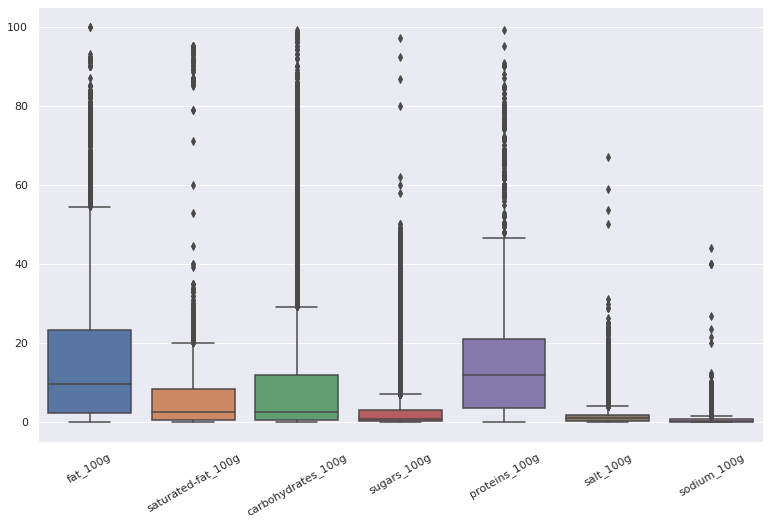

In [89]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [87]:
#sm_df_gr_transf = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))
#sm_df_gr_transf

In [88]:
#grouped.transform(lambda x: x.fillna(inplace=False))

In [ ]:
## faire fonction et apply par ligne ou boucler sur données uniques

In [ ]:
sm_df_main_mean = sm_df_groupby[main_cats].mean()
sm_df_main_mean

In [ ]:
sm_df.head()

In [ ]:
sm_df_main_mean['fat_100g']

In [ ]:
import math

def fill_grp_fat(row):
    if math.isnan(row['fat_100g']):
        cat = row['pnns_groups_1']
        print(cat)
        return sm_df_main_mean['fat_100g'][cat]
    else:
        return row['fat_100g']

In [ ]:
#sm_df['pnns_groups_1'].value_counts()

In [ ]:
sm_df['fat_100g'] = sm_df.apply(lambda x : fill_grp_fat(x), axis=1)

In [ ]:
## utiliser index (str) de sm_df_groupby

In [ ]:
#sm_df.filter(main_cats_grp).head()

### compl_cats : sat_fat / sodium => linearRegression

In [ ]:
# IterativeImputer avec estimator=LinearRegression()
#list2 = ["saturated-fat_100g", "sodium_100g"] 
complementary_cats

In [ ]:
sm_df.filter(complementary_cats).head()

In [ ]:
#sm_df_groupby.median().columns

In [ ]:
#sm_df_groupby.median()

In [ ]:
sm_df_groupby[complementary_cats].median()

### final_cats => 

In [ ]:
final_cats

In [30]:
#Reste des variables contenant des valeurs vides (sans list1, list2,  pnns_groups_1, pnns_groups_2) : 
# remplir soit avec la moyenne soit avec la mediane, en fonction de la distribution 
#- remplir avec la valeur la plus fréquente


In [ ]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')

###sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])

# Check nulls

In [ ]:
show_nulls(sm_df)

# export to csv

In [ ]:
#sm_df.reset_index()

sm_df.to_csv(path + 'clean_openfoodfacts_3.csv', index=False)
print('export finished !')

In [ ]:
ls -lh ./data